<a href="https://colab.research.google.com/github/raqueldias/ML4Bio/blob/main/Week_03_nb1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Building a Supervised Classifier for COVID-19 Proteomics

In this notebook, we will apply the core principles of supervised learning, feature standardization, classification metrics, and cohort validation using a real-world clinical dataset.

### Objectives
1. **Fetch and Load Datasets:** Download high-dimensional Olink proteomics data directly from a public database.
2. **Mitigate Data Leakage:** Filter out longitudinal autocorrelated time points to keep our samples truly independent.
3. **Scaling and Model fitting:** Scale the data and fit a Logistic Regression Classifier model to predict .
4. **Evaluate:** Track performance across our **Train set**, **Internal Validation set**, and an **Independent Testing Dataset**.
5. **Interpret the Biomarkers:** Extract and interpret linear coefficients to find biological signatures of disease severity.

### This dataset
The MGH Emergency Department COVID-19 Cohort dataset, originally published by Filbin et al. (2021) in Cell Reports Medicine, is a high-dimensional longitudinal proteomics dataset tracking 384 patients (306 COVID-19 positive individuals and 78 symptomatic but COVID-19 negative controls) who presented to the Massachusetts General Hospital emergency department. The dataset's features consist of absolute protein abundance levels quantified as Normalized Protein Expression (NPX) units on a $\log_2$ scale for approximately 1,400 protein biomarkers across four specialized Olink panels (inflammation, oncology, cardiometabolic, and neurology). The clinical outcomes recorded for these samples include a categorical binary label denoting COVID-19 status (positive vs. negative), longitudinal timepoints tracking repeated measures (Days 0, 3, 7, and 28), and a 28-day ordinal acuity severity scale based on the World Health Organization (WHO) framework, spanning five distinct categories from patient discharge to intubation and death.

More information at: https://www.sciencedirect.com/science/article/pii/S2666379121001154?via%3Dihub

Original data source: https://datadryad.org/dataset/doi:10.5061/dryad.stqjq2c7d

In [ ]:
# ==========================================
# Download and Unzip Data
# ==========================================
# We use curl to pull the open-access multi-omic dataset directly from Data Dryad.
print("Downloading dataset from Data Dryad...")
!curl -L -o data.zip https://github.com/raqueldias/ML4Bio/raw/refs/heads/main/data.zip
print("Unzipping files into the local runtime environment...")
!unzip -q data.zip
print("Done! Files extracted.")

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 18.9M  100 18.9M    0     0  13.8M      0  0:00:01  0:00:01 --:--:-- 23.4M
Unzipping files into the local runtime environment...
replace Biobank SSI/CyTOF.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
Done! Files extracted.


## Understanding the Cohort Distribution & Class Imbalance

In an ideal machine learning workflow, we prefer our **Training Dataset** to be larger than the test set. In this study, the dataset splits are structured as follows:

* **Training Cohort:** 68 total samples (~1,400 proteins). This is a very small sample size (many more features than samples), making the model susceptible to overfitting.
* **Validation/Testing Cohort:** 784 samples.

In clinical machine learning, your **Discovery Dataset** (where you train and tune your model) should ideally be larger, to have more statistical power, than your final test verification. The authors of this repository flipped this convention: they put 68 samples in "Training" and 784 samples in "Validation".

Following our course guidelines, we are going to perform a different setup:
* **Discovery Dataset (Train/Validation):** The original validation cohort (784 samples, ~1,420 biomarkers).
* **Independent Testing Dataset:** The original training cohort (68 samples, 1,463 biomarkers).

Let's load the data matrices and check their shapes using `pandas`.

Pandas is an open-source data manipulation and analysis library built for Python, designed to handle structured tabular data efficiently. The library introduces two main data structures: the Series (a one-dimensional labeled array) and the DataFrame (a two-dimensional, size-mutable data table with labeled rows and columns), which is the most useful one for our machine learning tasks. In computational biology and data science workflows, pandas is widely used for importing raw data from several file formats (such as CSV, Excel, or TXT), cleaning missing or malformed entries, filtering specific subsets of variables or features, and aligning differing omics datasets by matching their clinical sample identifiers. It fundamentally bridges the gap between raw data storage and advanced downstream machine learning algorithms, serving as the industry standard for programmatic data wrangling.

In [ ]:
# ==========================================
# Cohort Inversion & Loading
# ==========================================
import pandas as pd
import numpy as np

# Load our Discovery Data (pulled from the files inside the zip)
discovery_X = pd.read_csv("COVID-19/Validation/Validation_proteomics.csv", index_col=0)
discovery_y = pd.read_csv("COVID-19/Validation/Validation_outcome(WHO.0 >= 5).csv", index_col=0)

# Load our Independent Testing Data
independent_X = pd.read_csv("COVID-19/Training/Proteomics.csv", index_col=0)
independent_y = pd.read_csv("COVID-19/Training/Mild&ModVsSevere.csv", index_col=0)

print("--- Discovery Dataset (Raw) ---")
print(print(f"Features (Proteins): {discovery_X.shape[1]} | Samples: {discovery_X.shape[0]}"))
print("--- Independent Testing Dataset ---")
print(f"Features (Proteins): {independent_X.shape[1]} | Samples: {independent_X.shape[0]}")

# Check Class Counts
print("\n--- Discovery Dataset Outcomes ---")
print(discovery_y.value_counts())

print("\n--- Independent Testing Dataset Outcomes ---")
print(independent_y.value_counts())

--- Discovery Dataset (Raw) ---
Features (Proteins): 1420 | Samples: 784
None
--- Independent Testing Dataset ---
Features (Proteins): 1463 | Samples: 68

--- Discovery Dataset Outcomes ---
WHO.0 ≥ 5
False        659
True         125
Name: count, dtype: int64

--- Independent Testing Dataset Outcomes ---
Mild&ModVsSevere
0                   43
1                   25
Name: count, dtype: int64


## Mitigating Data Leakage

Our discovery dataset contains $n = 784$ total rows, but the original study only looked at 384 unique clinical patients! Because patients were sampled repeatedly across Day 0, Day 3, and Day 7, multiple rows share the same biological patient ID.

If we random-split this data now, a single patient's samples will leak into both our training and validation groups. This is a severe form of **Data Leakage** that will artificially inflate our performance metrics.

**The Fix:** We will use a regular expression filter on the sample indices to extract **only baseline samples (Day 0)**. This guarantees every row corresponds to an entirely unique individual.

In [ ]:
# ==========================================
# Clean & Filter for Day 0 Only
# ==========================================
# Look at sample index formats. They contain day trackers (e.g., '_D0', '_D3')
print("Sample Index Example:", discovery_X.index[:3].tolist())

# Keep rows where the index strings explicitly indicate Day 0
day0_mask = discovery_X.index.str.contains(r'_D0|_day0', case=False, na=False)

X_discovery_clean = discovery_X[day0_mask]
y_discovery_clean = discovery_y[day0_mask]

# Check Class Counts
print("\n--- Discovery Dataset Outcomes ---")
print(y_discovery_clean.value_counts())

# Drop columns (proteins) that contain any missing values
initial_protein_count = X_discovery_clean.shape[1]
X_discovery_clean = X_discovery_clean.dropna(axis=1)
dropped_count = initial_protein_count - X_discovery_clean.shape[1]
print(f"Dropped {dropped_count} proteins due to missing (NaN) values.")

# Ensure alignment and squeeze into a simple 1D array for labels
y_discovery_clean = y_discovery_clean.loc[X_discovery_clean.index].values.ravel()

print(f"Filtered Discovery Dataset down to unique patients: {X_discovery_clean.shape[0]} samples.")



Sample Index Example: ['1_D0', '1_D3', '2_D3']

--- Discovery Dataset Outcomes ---
WHO.0 ≥ 5
False        286
True          97
Name: count, dtype: int64
Dropped 3 proteins due to missing (NaN) values.
Filtered Discovery Dataset down to unique patients: 383 samples.


## Splitting the Discovery Dataset

Now, we will divide our clean discovery group into an internal **Training set (80%)** to fit model parameters and an **Internal Validation set (20%)** to safely check for overfitting before touching the external validation set.

In [ ]:
# ==========================================
# Train / Validation Split
# ==========================================
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_discovery_clean,
    y_discovery_clean,
    test_size=0.15,
    random_state=772026,
    stratify=y_discovery_clean # Ensures balanced class distributions in both splits
)

# Align our final Independent Testing sets to match features found in our discovery models
shared_proteins = X_train.columns.intersection(independent_X.columns)
X_train = X_train[shared_proteins]
X_val = X_val[shared_proteins]
X_test = independent_X[shared_proteins]
y_test = independent_y.values.ravel()

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Internal Validation set size: {X_val.shape[0]} samples")
print(f"Independent Test set size: {X_test.shape[0]} samples")
print(f"Total Shared Protein Biomarkers evaluated: {X_train.shape[1]}")

Training set size: 325 samples
Internal Validation set size: 58 samples
Independent Test set size: 68 samples
Total Shared Protein Biomarkers evaluated: 1417


## Leakage-Free Standardization & Training

As taught in class, feature scales matter significantly when working with linear classifiers. To avoid structural data leakage, we **must only calculate scaling properties from our training set**.

We will:
1. `.fit_transform()` exclusively on the **Training set** to extract the means and standard deviations.
2. Use those identical training parameters to `.transform()` the **Validation** and **Independent Test** sets.
3. Fit a Logistic Regression classifier.

In [ ]:
# ==========================================
# Data Scaling & Model Fitting
# ==========================================
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# 1. Initialize Scaler
scaler = StandardScaler()

# 2. Extract properties and transform subsets step-by-step
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# 3. Fit a Linear Logistic Regression Classifier (L1 Penalty enforces feature sparsity)
model = LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced', C=0.1, random_state=772026)
model.fit(X_train_scaled, y_train)

print("Model training completed.")

Model training completed.


## Evaluating Model Performance

Let's compute our core metrics: Confusion Matrix, Accuracy, Precision, Recall, F1-Score, and ROC-AUC—to see how well our model generalizes across all three dataset levels.

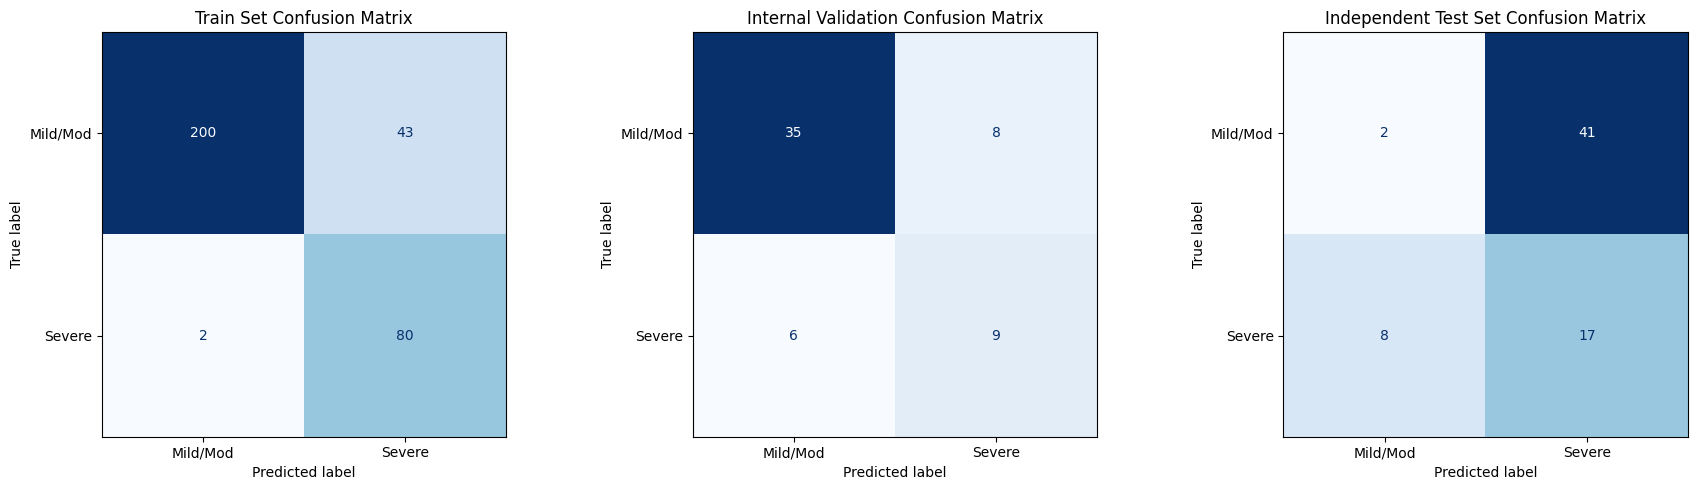


=== FINAL CLASSIFICATION REPORT ===


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Train Set,0.862,0.650,0.976,0.780,0.956
Internal Validation,0.759,0.529,0.600,0.562,0.820
Independent Test Set,0.279,0.293,0.680,0.410,0.191


In [ ]:
# ==========================================
# Calculate and Plot Performance
# ==========================================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

datasets = {
    "Train Set": (X_train_scaled, y_train),
    "Internal Validation": (X_val_scaled, y_val),
    "Independent Test Set": (X_test_scaled, y_test)
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics_summary = {}

for idx, (name, (X_group, y_group)) in enumerate(datasets.items()):
    # Predictions
    y_pred = model.predict(X_group)
    y_proba = model.predict_proba(X_group)[:, 1]

    # Store metrics
    metrics_summary[name] = {
        "Accuracy": accuracy_score(y_group, y_pred),
        "Precision": precision_score(y_group, y_pred),
        "Recall": recall_score(y_group, y_pred),
        "F1-Score": f1_score(y_group, y_pred),
        "ROC-AUC": roc_auc_score(y_group, y_proba)
    }

    # Plot Confusion Matrices side-by-side
    cm = confusion_matrix(y_group, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Mild/Mod", "Severe"])
    disp.plot(ax=axes[idx], cmap="Blues", colorbar=False)
    axes[idx].set_title(f"{name} Confusion Matrix")

plt.tight_layout()
plt.show()

# Print out a cleanly organized DataFrame summary of results
df_metrics = pd.DataFrame(metrics_summary).T
print("\n=== FINAL CLASSIFICATION REPORT ===")
display(df_metrics.round(3))

If you look at the Train Set, performance might look near-perfect. However, looking at the performance degradation on the Internal Validation and Independent Test Set will explicitly illustrate a more realistic scenario if we plan to deploy this model for clinical use.

The paper's main classifier result is a mean AUC of 0.81-0.86, obtained from internal validation on day 0 proteins for severity prediction. The paper also explicitly says that an independent validation dataset is still needed, so it does not report an external, independent test-set accuracy for that model.

Reference: https://www.sciencedirect.com/science/article/pii/S2666379121001154#sec2

## Interpreting The Model: Extracting Biological Candidate Biomarkers

Because we standardized properly before training, we can directly interpret the directionality and influence of the linear weights (coefficients) to isolate which proteins are pushing the model toward predicting severe COVID-19.

In [ ]:
# ==========================================
# Coefficient Extraction
# ==========================================
coefficients = model.coef_[0]

# Link back to original protein names
coef_df = pd.DataFrame({
    'Protein': X_train.columns,
    'Coefficient': coefficients
})

# Filter out unselected proteins
important_biomarkers = coef_df[coef_df['Coefficient'] != 0].sort_values(by='Coefficient', ascending=False)

print(f"Total active predictive biomarkers discovered: {len(important_biomarkers)}")
print("\nTop 5 Proteins Associated with Severe Outcomes (Positive Coefficients):")
display(important_biomarkers.head(5))

print("\nTop 5 Proteins Associated with Protective/Mild Outcomes (Negative Coefficients):")
display(important_biomarkers.tail(5))

Total active predictive biomarkers discovered: 57

Top 5 Proteins Associated with Severe Outcomes (Positive Coefficients):


,Protein,Coefficient
118,BID,0.438280
826,LTA,0.281310
690,IL17A,0.192628
969,OBP2B,0.189779
1123,RGMA,0.113019



Top 5 Proteins Associated with Protective/Mild Outcomes (Negative Coefficients):


,Protein,Coefficient
109,BAIAP2,-0.158287
348,CRIP2,-0.189917
658,IDI2,-0.198269
1189,SFTPA2,-0.206263
721,IL6,-0.299823


## Interpreting the Linear Signatures (What do these coefficients mean?)

When analyzing the output of a standardized linear classifier like Logistic Regression, the **sign** (positive or negative) and **magnitude** (distance from zero) of the coefficients provide a direct mathematical window into the biology of the disease.

Because we used `StandardScaler` to bring all protein features onto the exact same scale before training, we can compare these coefficients directly without worrying about differences in raw measurement units.

### 1. Positive Coefficients = Association with Severity
A **positive coefficient** means that as the abundance of that specific protein increases, the model's predicted probability that the patient belongs to the "Severe" class goes up.
* **Biological Translation:** These proteins are your **candidate biomarkers of disease severity, progression, or hyper-inflammation**.
* *Example:* In our output, **BID** (Coefficient: `0.44`) and **LTA** (Coefficient: `0.28`) have the highest positive weights. This indicates that the model heavily relies on elevated levels of these proteins to identify severe COVID-19 cases.

### 2. Negative Coefficients = Protective / Mild Associations
A **negative coefficient** means an inverse relationship: as the abundance of that protein increases, the model's predicted probability of a severe outcome *decreases* (meaning the probability of a Mild/Moderate outcome increases).
* **Biological Translation:** These proteins are your **candidate biomarkers of baseline health, protection, or a controlled immune response**.
* *Example:* **IL6** has a strong negative coefficient (`-0.30`), meaning the model strongly associates higher baseline expression of this specific panel with non-severe/mild pathways.

### A Crucial Caution
Always remember that **magnitude and sign are only directional in linear models**. Feature importance scores for non-linear models are explored with a different approach (more information coming soon!).